In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data[:, :2]   # take first 2 features only
y = data.target

print(X.shape)  
print(y[:5]) 

(569, 2)
[0 0 0 0 0]


In [8]:
X_train = data.data[:, :2]    
y_train = data.target         
m, n = X_train.shape

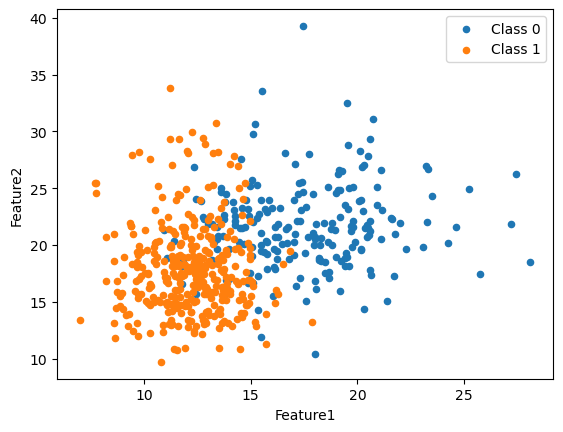

In [14]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train ==1, 1], color='tab:orange', label='Class 1', s=20)
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

IMPLEMENTATION PLAN

1.Sigmoid function

2.Cost function

3.Gradient function

4.Gradient Decent function

5.Prediction Function 

In [15]:
#sigmoid functiom
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    

In [58]:
#cost function
def cost_function(X, y, w, b):
    y = y.flatten()    # fix shape
    m = len(y)
    total_cost = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, 1e-7, 1 - 1e-7)
        total_cost += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    return (1/m) * total_cost

In [59]:
def gradient_function(X, y, w, b):
    y = y.flatten()    # fix shape from (569,1) to (569,)
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0
    
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        grad_w += (g - y[i]) * X[i]
        grad_b += (g - y[i])
    
    grad_w = grad_w / m
    grad_b = grad_b / m
    
    return grad_b, grad_w

In [60]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0
    y = y.flatten() 

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}")
    
    return w, b

In [65]:
def predict(X, w, b):
    m = X.shape[0]       
    preds = np.zeros(m)
    
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        preds[i] = 1 if g >= 0.5 else 0
    
    return predict

In [72]:
# Normalize
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_scaled = (X_train - X_mean) / X_std

# Train on scaled data
learning_rate = 0.01
iterations = 10000
final_w, final_b = gradient_descent(X_scaled, y_train, learning_rate, iterations)

# Accuracy
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6913388757230433
Iteration 1000: Cost 0.3198642242708535
Iteration 2000: Cost 0.28432283695194654
Iteration 3000: Cost 0.2716863819914328
Iteration 4000: Cost 0.2655629454058543
Iteration 5000: Cost 0.262146562553982
Iteration 6000: Cost 0.26007972165513943
Iteration 7000: Cost 0.25876179296135193
Iteration 8000: Cost 0.2578899145597792
Iteration 9000: Cost 0.25729732024357377
Training Accuracy: 0.00%


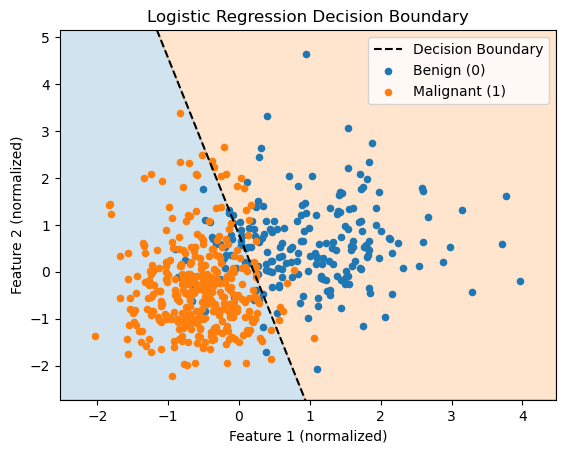

In [68]:
m_slope = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
ymin, ymax = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m_slope * xd + c

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_scaled[y_train == 0, 0], X_scaled[y_train == 0, 1], color='tab:blue', label='Benign (0)', s=20)
plt.scatter(X_scaled[y_train == 1, 0], X_scaled[y_train == 1, 1], color='tab:orange', label='Malignant (1)', s=20)

plt.legend()
plt.xlabel('Feature 1 (normalized)')
plt.ylabel('Feature 2 (normalized)')
plt.title('Logistic Regression Decision Boundary')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# ── 1. Load Data ─────────────────────────────────────
data = load_breast_cancer()
X_train = data.data[:, :2]
y_train = data.target.flatten()

print(f"X shape: {X_train.shape}")
print(f"y shape: {y_train.shape}")
print(f"y sample: {y_train[:5]}")

# ── 2. Normalize ─────────────────────────────────────
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_scaled = (X_train - X_mean) / X_std

# ── 3. Sigmoid ───────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ── 4. Cost Function ─────────────────────────────────
def cost_function(X, y, w, b):
    m = X.shape[0]
    total_cost = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = np.clip(sigmoid(z), 1e-7, 1 - 1e-7)
        total_cost += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    return (1/m) * total_cost

# ── 5. Gradient Function ─────────────────────────────
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        grad_w += (g - y[i]) * X[i]
        grad_b += (g - y[i])
    return grad_b/m, grad_w/m

# ── 6. Gradient Descent ──────────────────────────────
def gradient_descent(X, y, alpha, iterations):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b):.4f}")
    return w, b

# ── 7. Predict ───────────────────────────────────────
def predict(X, w, b):
    m = X.shape[0]
    preds = np.zeros(m)
    for i in range(m):
        z = np.dot(w, X[i]) + b
        preds[i] = 1 if sigmoid(z) >= 0.5 else 0
    return preds

# ── 8. Train ─────────────────────────────────────────
final_w, final_b = gradient_descent(X_scaled, y_train, 0.01, 10000)

# ── 9. Accuracy ──────────────────────────────────────
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"\nTraining Accuracy: {accuracy:.2f}%")

X shape: (569, 2)
y shape: (569,)
y sample: [0 0 0 0 0]
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3199
Iteration 2000: Cost 0.2843
Iteration 3000: Cost 0.2717
Iteration 4000: Cost 0.2656
Iteration 5000: Cost 0.2621
Iteration 6000: Cost 0.2601
Iteration 7000: Cost 0.2588
Iteration 8000: Cost 0.2579
Iteration 9000: Cost 0.2573

Training Accuracy: 89.10%


In [3]:
def gradient_descent_l2(X, y, alpha, iterations, lambda_):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        grad_w += (lambda_/m) * w      # L2 term — shrinks weights
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        if i % 1000 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {i}: Cost {cost:.4f}")

    return w, b

# Test L2
print("\nL2 Regularization:")
for lambda_ in [0, 0.1, 1, 10]:
    w_l2, b_l2 = gradient_descent_l2(X_scaled, y_train, 0.01, 10000, lambda_)
    acc = np.mean(predict(X_scaled, w_l2, b_l2) == y_train) * 100
    print(f"λ={lambda_:4} → Accuracy: {acc:.2f}% | Weights: {w_l2}")
    


L2 Regularization:
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3199
Iteration 2000: Cost 0.2843
Iteration 3000: Cost 0.2717
Iteration 4000: Cost 0.2656
Iteration 5000: Cost 0.2621
Iteration 6000: Cost 0.2601
Iteration 7000: Cost 0.2588
Iteration 8000: Cost 0.2579
Iteration 9000: Cost 0.2573
λ=   0 → Accuracy: 89.10% | Weights: [-3.34506978 -0.88778192]
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3200
Iteration 2000: Cost 0.2845
Iteration 3000: Cost 0.2718
Iteration 4000: Cost 0.2657
Iteration 5000: Cost 0.2623
Iteration 6000: Cost 0.2602
Iteration 7000: Cost 0.2589
Iteration 8000: Cost 0.2580
Iteration 9000: Cost 0.2574
λ= 0.1 → Accuracy: 89.10% | Weights: [-3.32316773 -0.88402542]
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3208
Iteration 2000: Cost 0.2857
Iteration 3000: Cost 0.2733
Iteration 4000: Cost 0.2673
Iteration 5000: Cost 0.2639
Iteration 6000: Cost 0.2619
Iteration 7000: Cost 0.2605
Iteration 8000: Cost 0.2596
Iteration 9000: Cost 0.2590
λ=   1 → Accuracy: 88.7

In [4]:
def gradient_descent_l1(X, y, alpha, iterations, lambda_):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        grad_w += (lambda_/m) * np.sign(w)   # L1 term — kills weak weights
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        if i % 1000 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {i}: Cost {cost:.4f}")

    return w, b

# Test L1
print("\nL1 Regularization:")
for lambda_ in [0, 0.1, 1, 10]:
    w_l1, b_l1 = gradient_descent_l1(X_scaled, y_train, 0.01, 10000, lambda_)
    acc = np.mean(predict(X_scaled, w_l1, b_l1) == y_train) * 100
    print(f"λ={lambda_:4} → Accuracy: {acc:.2f}% | Weights: {w_l1}")
    


L1 Regularization:
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3199
Iteration 2000: Cost 0.2843
Iteration 3000: Cost 0.2717
Iteration 4000: Cost 0.2656
Iteration 5000: Cost 0.2621
Iteration 6000: Cost 0.2601
Iteration 7000: Cost 0.2588
Iteration 8000: Cost 0.2579
Iteration 9000: Cost 0.2573
λ=   0 → Accuracy: 89.10% | Weights: [-3.34506978 -0.88778192]
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3200
Iteration 2000: Cost 0.2844
Iteration 3000: Cost 0.2718
Iteration 4000: Cost 0.2656
Iteration 5000: Cost 0.2622
Iteration 6000: Cost 0.2601
Iteration 7000: Cost 0.2588
Iteration 8000: Cost 0.2579
Iteration 9000: Cost 0.2574
λ= 0.1 → Accuracy: 89.10% | Weights: [-3.33734005 -0.88493368]
Iteration 0: Cost 0.6913
Iteration 1000: Cost 0.3208
Iteration 2000: Cost 0.2853
Iteration 3000: Cost 0.2726
Iteration 4000: Cost 0.2664
Iteration 5000: Cost 0.2629
Iteration 6000: Cost 0.2608
Iteration 7000: Cost 0.2594
Iteration 8000: Cost 0.2585
Iteration 9000: Cost 0.2579
λ=   1 → Accuracy: 88.9

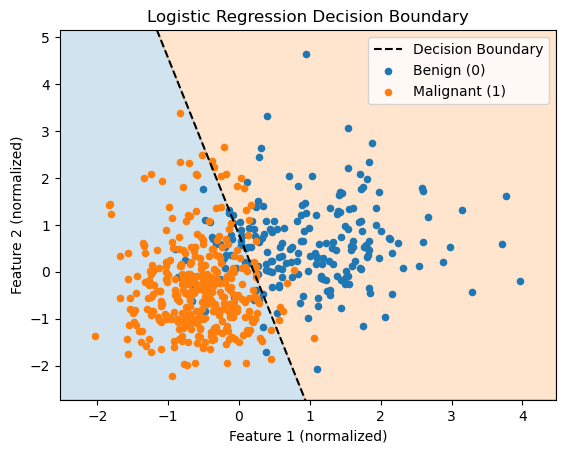

In [5]:
m_slope = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
ymin, ymax = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m_slope * xd + c

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_scaled[y_train == 0, 0], X_scaled[y_train == 0, 1], color='tab:blue', label='Benign (0)', s=20)
plt.scatter(X_scaled[y_train == 1, 0], X_scaled[y_train == 1, 1], color='tab:orange', label='Malignant (1)', s=20)

plt.legend()
plt.xlabel('Feature 1 (normalized)')
plt.ylabel('Feature 2 (normalized)')
plt.title('Logistic Regression Decision Boundary')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()